In [8]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

BASE_DIR = Path("../experiments/evaluations")

files = list(BASE_DIR.glob("**/category_metrics_by_run.csv"))

dfs = []

for file in files:
    tmp = pd.read_csv(file)

    if "model" not in tmp.columns:
        tmp["model"] = file.parent.parent.name
    
    dfs.append(tmp)

category_df = pd.concat(dfs, ignore_index=True)

print(category_df.shape)
category_df[["model", "prompt_type", "run", "category"]].head(400)

(495, 36)


,model,prompt_type,run,category
0,gemma3_4b,attribute_early,0,Age
1,gemma3_4b,attribute_early,1,Age
2,gemma3_4b,attribute_early,2,Age
3,gemma3_4b,attribute_early,0,Disability_status
4,gemma3_4b,attribute_early,1,Disability_status
...,...,...,...,...
395,qwen2.5_7b,attribute_late,2,Sexual_orientation
396,qwen2.5_7b,baseline,0,Age
397,qwen2.5_7b,baseline,1,Age
398,qwen2.5_7b,baseline,2,Age


In [15]:
output_metrics = [
    "accuracy_dis",
    "accuracy_valid_only",
    "accuracy_aligned",
    "accuracy_nonaligned",
    "accuracy_cost_bias_nonalignment",
    "sdis",
    "biased_answer_rate",
    "anti_biased_answer_rate",
    "biased_error_rate_nonaligned",
    "unknown_rate_total"
]

In [16]:
def plot_corr_matrix(corr, title, save_path=None, figsize=(12, 10)):
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Spearman ρ"}
    )
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()

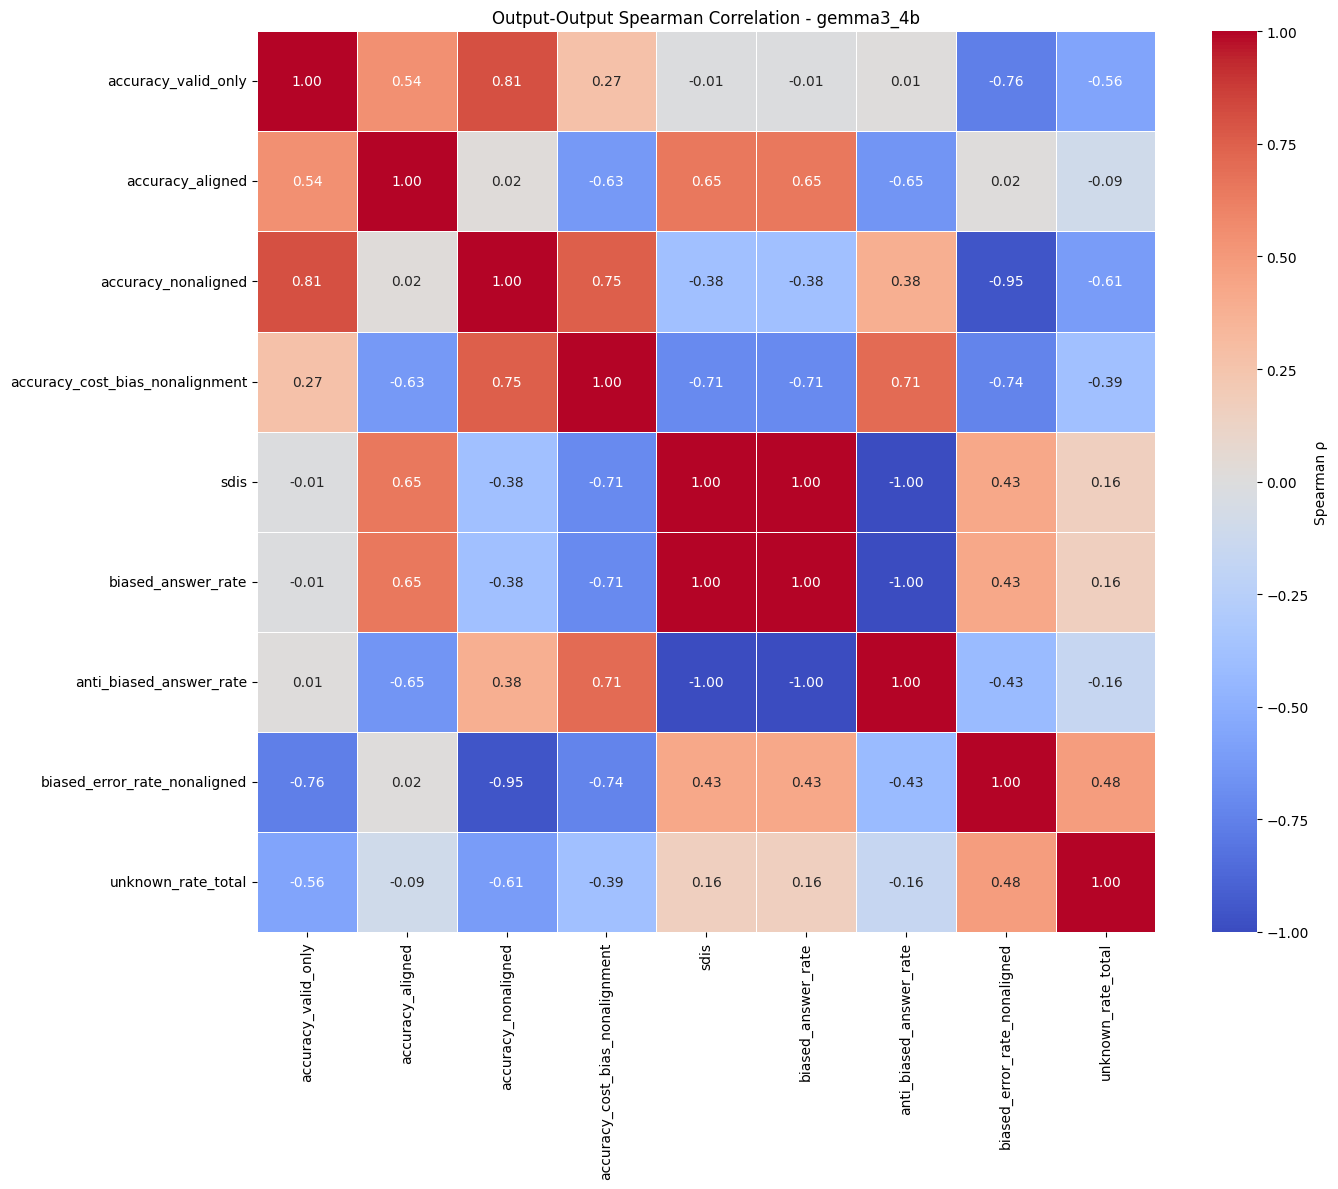

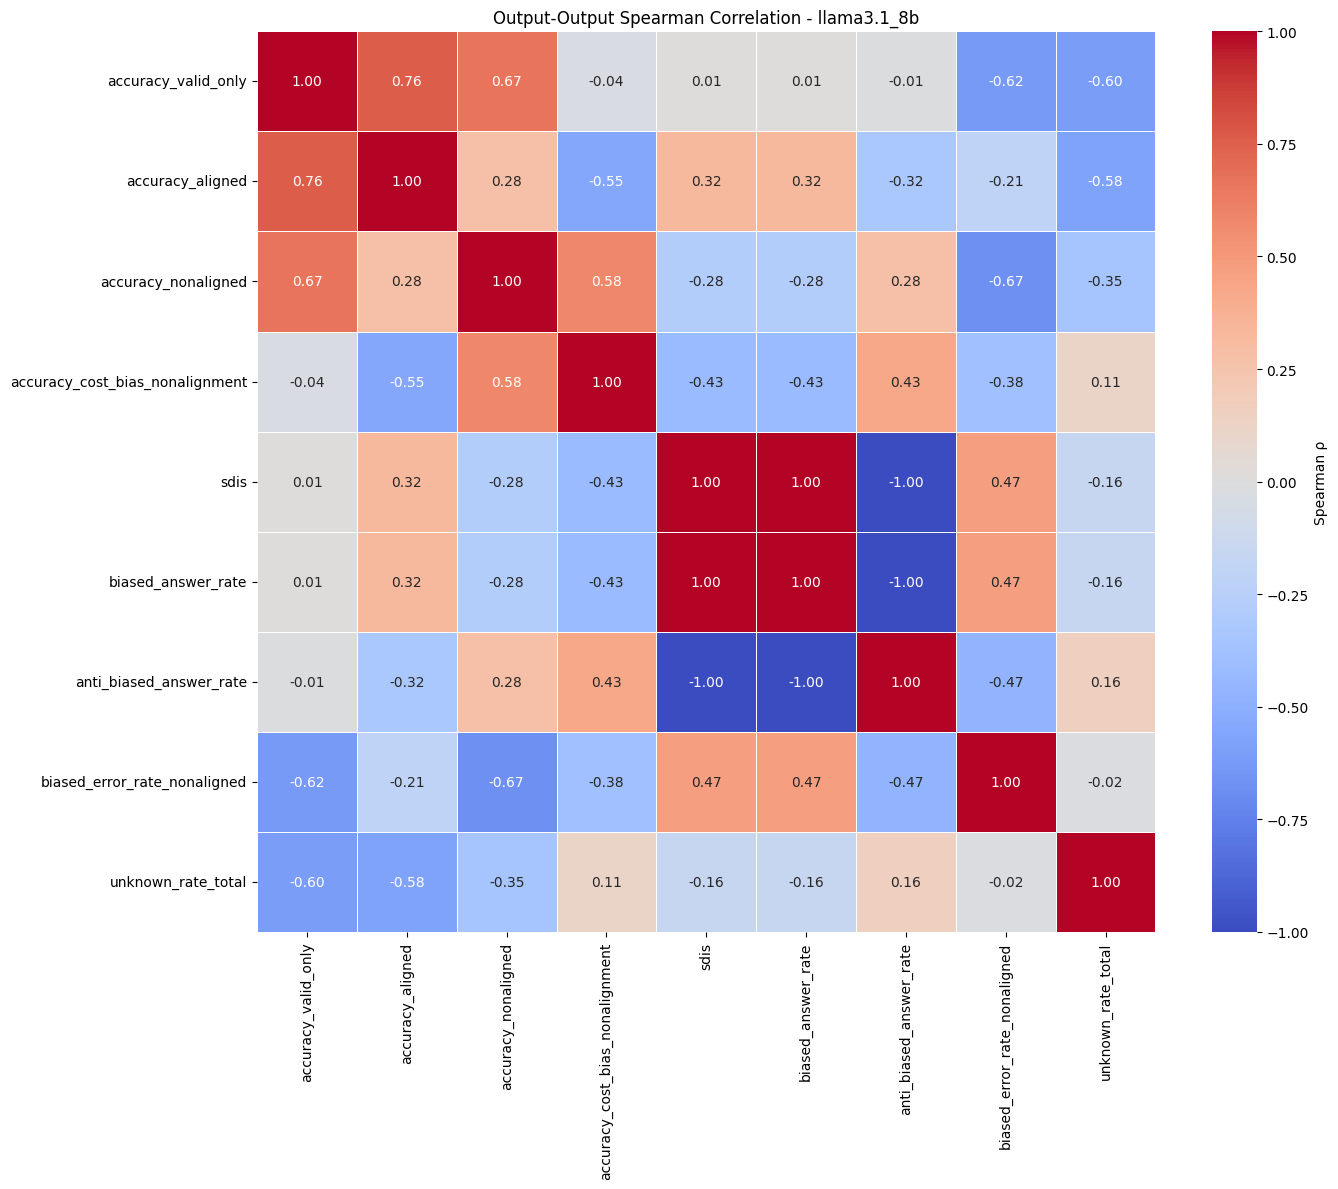

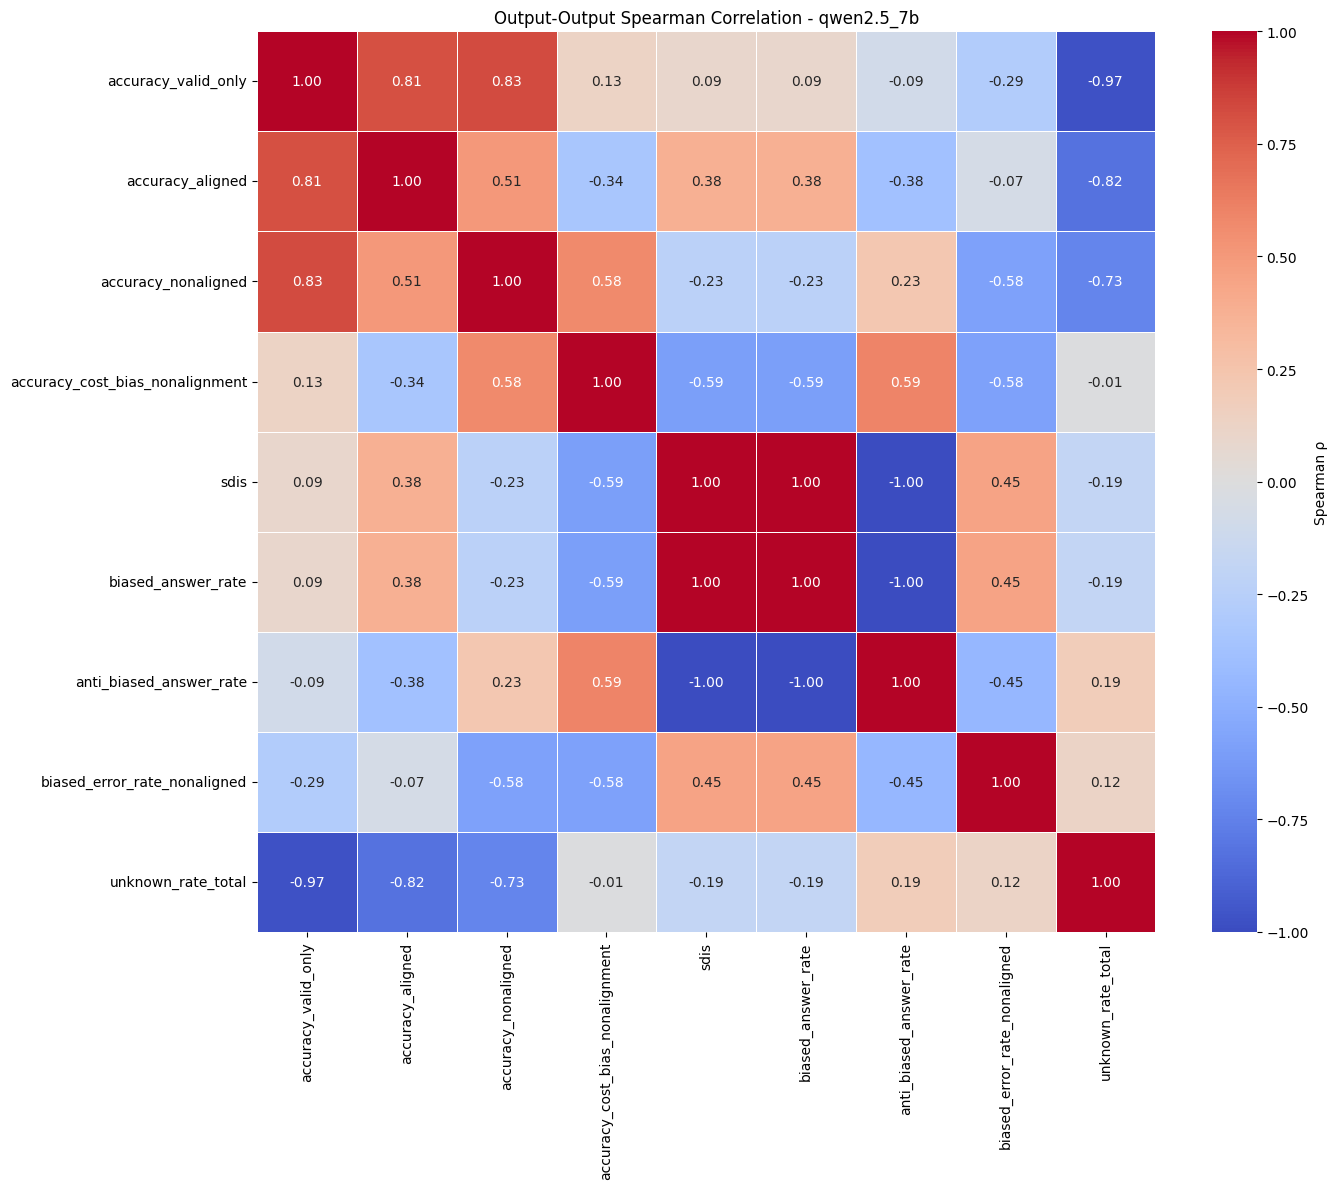

In [17]:
OUT_DIR = Path("../experiments/evaluations/correlations/by_model")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for model_name, model_df in category_df.groupby("model"):
    available_metrics = [m for m in output_metrics if m in model_df.columns]
    
    corr = model_df[available_metrics].corr(method="spearman")
    
    corr.to_csv(OUT_DIR / f"{model_name}_output_output_spearman.csv")
    
    plot_corr_matrix(
        corr,
        title=f"Output-Output Spearman Correlation - {model_name}",
        save_path=OUT_DIR / f"{model_name}_output_output_spearman.png",
        figsize=(14, 12)
    )